## COHORT RETENTION ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', None)

### Period of Analysis
01 Dec 2018 - 01 Dec 2021

### Problem Statement
To understand customers retention rate from the jewelery store

### Goals:
Measure customers retention rate\
Identify patterns and trends\
Gain insights and give recommendation to marketing team for campaign purpose

In [ ]:
#Datasets: 'https://www.kaggle.com/datasets/mkechinov/ecommerce-purchase-history-from-jewelry-store'

hdList = ['Order Date Time', 'Order ID', 'Purchased Product ID', 'Quantity', 
          'Category ID', 'Category Name', 'Brand ID', 'Price in USD', 'User ID', 'Product Gender',
         'Color', 'Material', 'Stone']

df_Raw = pd.read_csv('jewelry.csv', names=hdList)
df_Raw.head(3)

,Order Date Time,Order ID,Purchased Product ID,Quantity,Category ID,Category Name,Brand ID,Price in USD,User ID,Product Gender,Color,Material,Stone
0,2018-12-01 11:40:29 UTC,1924719191579951782,1842195256808833386,1,1.806829e+18,jewelry.earring,0.0,561.51,1.515916e+18,NaN,red,gold,diamond
1,2018-12-01 17:38:31 UTC,1924899396621697920,1806829193678291446,1,1.806829e+18,NaN,NaN,212.14,1.515916e+18,NaN,yellow,gold,NaN
2,2018-12-02 13:53:42 UTC,1925511016616034733,1842214461889315556,1,1.806829e+18,jewelry.pendant,1.0,54.66,1.515916e+18,f,white,gold,sapphire


In [31]:
df_Raw['Order Date Time'] = pd.to_datetime(df_Raw['Order Date Time'])
df_Raw = df_Raw.astype({'Order ID' : 'str', 'Purchased Product ID' : 'str', 'User ID' : 'str'})
df_Raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 95911 entries, 0 to 95910
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   Order Date Time       95911 non-null  datetime64[us, UTC]
 1   Order ID              95911 non-null  str                
 2   Purchased Product ID  95911 non-null  str                
 3   Quantity              95911 non-null  int64              
 4   Category ID           90559 non-null  float64            
 5   Category Name         85978 non-null  str                
 6   Brand ID              91126 non-null  float64            
 7   Price in USD          90559 non-null  float64            
 8   User ID               90559 non-null  str                
 9   Product Gender        47743 non-null  str                
 10  Color                 88251 non-null  str                
 11  Material              90449 non-null  str                
 12  Stone          

In [32]:
#Current transaction period
df_Raw['Month'] = df_Raw['Order Date Time'].dt.to_period('M')
df_Raw['Quarter'] = df_Raw['Order Date Time'].dt.to_period('Q')

In [33]:
#User value counts (to check whether cohort analysis can be done or not)
User_Top30 = df_Raw['User ID'].value_counts().reset_index().head(30)

In [34]:
#Check user transactions range; from Top 30 Users Purchases
df_Raw['Top 30'] = np.where(df_Raw['User ID'].isin(User_Top30['User ID']), True, False)
df_User_Top30 = df_Raw[( df_Raw['Top 30'] == True )].groupby(['User ID', 'Month'], as_index=False)[['User ID','Month','Order ID']].agg({'Order ID':'count'})

pvt_Top30 = df_User_Top30.pivot_table(index='User ID', columns='Month', values='Order ID')

Based on Top 30 Users' purchases behavior, it's hard to draw a conclusion how to define a cohort.\
Therefore, sample will be taken randomly. 

In [35]:
#Define users with more than 1 transaction
Users = df_Raw.groupby('User ID', as_index=False)[['Order ID']].count()
Users = Users[(Users['Order ID']>10)]

In [36]:
# Sample
User_Samp = Users.sample(15, random_state=55855)
User_Samp = User_Samp.reset_index().drop(columns='index')

df_Raw['Sample'] = np.where(df_Raw['User ID'].isin(User_Samp['User ID']), True, False)
df_User_Samp = df_Raw[( df_Raw['Sample'] == True )].groupby(['User ID', 'Month'], as_index=False)[['User ID','Month','Order ID']].agg({'Order ID':'count'})

pvt_Sample = df_User_Samp.pivot_table(index='User ID', columns='Month', values='Order ID')

Based on the samples taken, it's hard to draw conclusion the cohort periods.\
As top 30 customers purchases pattern, severals are noticed to repurchase after 3 months.\
Therefore, cohort period will be defined as quarter.\
As the beginning and ending of the datasets doesn't fully represent a quarter, transactions within that period will be excluded for this analysis.

In [43]:
df = df_Raw[ (df_Raw['Quarter']!='2018Q4') & (df_Raw['Quarter']!='2021Q4') ]

In [44]:
#Define Cohort Period by Quarter
df['Cohort'] = df.groupby('User ID')['Quarter'].transform('min')
df['Cohort'].value_counts()

Cohort
2019Q1    11883
2021Q1    10342
2020Q4     9643
2021Q3     9574
2021Q2     8312
2019Q4     6020
2020Q1     5603
2020Q3     4731
2019Q3     3949
2019Q2     3873
2020Q2     3728
Freq: Q-DEC, Name: count, dtype: int64

In [45]:
#Grouping
df_Retention = df[['User ID','Cohort','Quarter']]
df_Retention.drop_duplicates(inplace=True)
df_Retention.sort_values(by=['Cohort','Quarter']).reset_index(inplace=True)
df_Retention.head(3)

,User ID,Cohort,Quarter
122,1.5159156250786368e+18,2019Q1,2019Q1
123,1.5159156250865257e+18,2019Q1,2019Q1
124,1.5159156252216993e+18,2019Q1,2019Q1


In [46]:
#Count Aggregation
df_Rtn = df_Retention.groupby(['Cohort','Quarter'], as_index=False)[['User ID']].count().rename(columns={'User ID':'Count'})
df_Rtn.head(3)

,Cohort,Quarter,Count
0,2019Q1,2019Q1,636
1,2019Q1,2019Q2,128
2,2019Q1,2019Q3,120


In [47]:
#Period Distance
df_Rtn['Period'] = (df_Rtn['Quarter'] - df_Rtn['Cohort']).apply(lambda x: x.n)
df_Rtn.head(3)

,Cohort,Quarter,Count,Period
0,2019Q1,2019Q1,636,0
1,2019Q1,2019Q2,128,1
2,2019Q1,2019Q3,120,2


In [48]:
#Pivot Table
pvt_Rtn = df_Rtn.pivot_table(index='Cohort',columns='Period',values='Count')

In [49]:
#Count Percentage
pvt_Rtn_Percent = pvt_Rtn.divide(pvt_Rtn.iloc[:,0],axis=0)
pvt_Rtn_Percent

Period,0,1,2,3,4,5,6,7,8,9,10
Cohort,,,,,,,,,,,
2019Q1,1.0,0.201258,0.188679,0.283019,0.238994,0.097484,0.171384,0.207547,0.146226,0.132075,0.124214
2019Q2,1.0,0.155211,0.277162,0.188470,0.093126,0.150776,0.159645,0.121951,0.082040,0.066519,NaN
2019Q3,1.0,0.250877,0.201754,0.057895,0.138596,0.171930,0.087719,0.077193,0.068421,NaN,NaN
2019Q4,1.0,0.205298,0.051088,0.126774,0.192053,0.082308,0.069063,0.052980,NaN,NaN,NaN
2020Q1,1.0,0.089567,0.131890,0.171260,0.110236,0.084646,0.075787,NaN,NaN,NaN,NaN
2020Q2,1.0,0.106719,0.119895,0.077734,0.068511,0.038208,NaN,NaN,NaN,NaN,NaN
2020Q3,1.0,0.155956,0.089342,0.061912,0.065831,NaN,NaN,NaN,NaN,NaN,NaN
2020Q4,1.0,0.061916,0.029711,0.026595,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021Q1,1.0,0.034058,0.023732,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


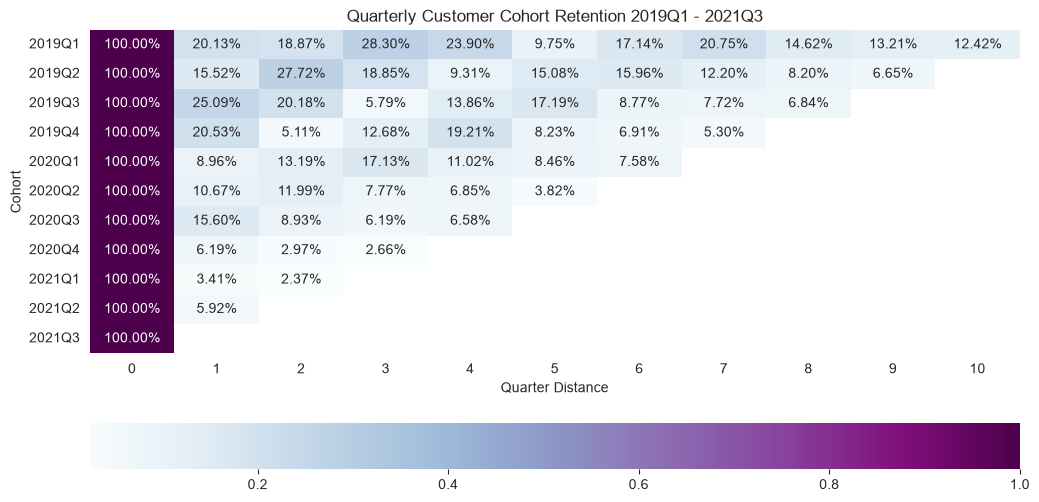

In [80]:
#Heatmap
plt.figure(figsize=(12,6))

sns.set_style('white')
sns.heatmap(data=pvt_Rtn_Percent,annot=True,fmt='.2%',
           cbar_kws={'orientation':'horizontal'},
           cmap='BuPu')
plt.title('Quarterly Customer Cohort Retention 2019Q1 - 2021Q3')
plt.xlabel('Quarter Distance')
plt.ylabel('Cohort')
plt.show()

#### Insights:
Highest retention rate: 28%\
During period 2020-Q1: all customers retention rate plummeted to below 10%.\
2020-Q1 was the start of the pandemic COVID-19.\
Customers retention rebounded in period 2020-Q2 and Q3 ranging from 10% to 20%.\
Starting period 2020-Q4, retention rate dropped again to below 15%.

Addition:\
More sales data are needed for further analysis, to understand retention rate during normal periods.\
Customers in cohort 2019-Q1 showed higher retention rate compared to the others (except 2020-Q1).

In [52]:
#Dictionary to Map Cohort Period 0
df_Cohort = df_Rtn[df_Rtn['Period']==0][['Cohort','Count']].reset_index().drop(columns='index')
#df_Cohort['Cohort'] = df_Cohort['Cohort'].astype('str')
Dict_Cohort = df_Cohort.set_index('Cohort')['Count'].to_dict()

In [54]:
# Create mapping list
df_Cohort = df_Rtn[df_Rtn['Period']==0][['Cohort','Count']]
df_Cohort.set_index("Cohort",inplace=True)
df_Rtn['Percentage'] = round( df_Rtn['Count'] / df_Rtn['Cohort'].map(Dict_Cohort) * 100 , 2)

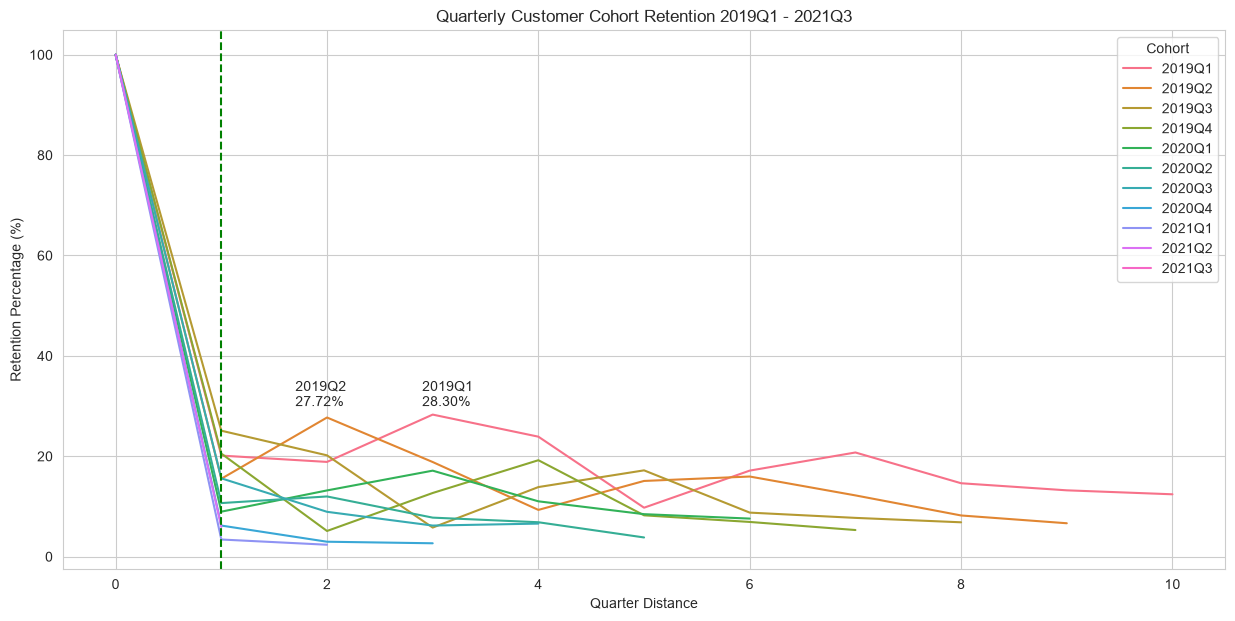

In [76]:
#Create lineplot
plt.figure(figsize=(15,7))

#Cohort lineplot
sns.set_style('whitegrid')
sns.lineplot(data=df_Rtn,x='Period',y='Percentage',hue='Cohort')
plt.axvline(x=1,linestyle='--',color='green')
plt.text(2.9,30,'2019Q1\n28.30%')
plt.text(1.7,30,'2019Q2\n27.72%')

plt.xlabel('Quarter Distance')
plt.ylabel('Retention Percentage (%)')
plt.title('Quarterly Customer Cohort Retention 2019Q1 - 2021Q3')
plt.show()


#### Insights:
Highest retention rate: 28%, only from the first cohort (2019-Q1).\
Overall, customers from cohort 2019-Q1 and 2019-Q2 showed better retention rate compared to others.

Addition:\
Further analysis needed for customers in cohort 2019-Q1. Whether there are special marketing campaign or treatment.\
More sales data are needed for further analysis, to understand retention rate during normal periods.

### Force Majeure: COVID-19 Pandemic


#### Year 2020:
Initial Collapse (Early 2020): Lockdowns caused a historic global contraction of about 3.5% to 7% in 2020, marking the deepest post-WWII recession but also the shortest (lasting March–April 2020 in major markets like the U.S.).

#### Year 2021
The Sharp Rebound (2021): Backed by massive fiscal and monetary stimulus and vaccine rollouts, the global economy surged back with roughly 5.6% to 6% growth in 2021, allowing global trade in goods to surpass 2019 levels by early 2021.

#### Year 2022-2023
Stalls and Inflation (2022–2023): New virus variants, supply-chain constraints, and the energy crisis tied to geopolitical conflicts slowed momentum, though overall economic activity normalized by late 2023.